# Bloque 3 — Análisis Exploratorio + Experimentación
**Cadena retail multiformato · Centroamérica** · datos ene-2024 a jun-2025.

Notebook reproducible: el análisis se ejecuta con DuckDB (SQL ANSI sobre los CSV), pandas y scipy.

**Decisiones de calidad heredadas del Bloque 0:**
- GMV = `Σ(unit_price × quantity)` sobre `status='COMPLETED'` (fuente de verdad, desagregable).
- Devoluciones excluidas por `status` (los `RETURNED` tienen monto **positivo**, no negativo).
- Cohortes solo sobre `loyalty_card=TRUE` (60% de tx sin `customer_id`, por diseño).
- A/B: se excluyen TIENDA_008 y TIENDA_037 (doble asignación detectada en auditoría).


In [2]:
import duckdb, pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi':100,'font.size':10,'axes.grid':True,'grid.alpha':.3})

# Ruta a los 6 CSV. En el repo: ./data  (ajustar si corre en otro entorno)
DATA = "./data"

con = duckdb.connect()
for t in ['transactions','transaction_items','stores','products','vendors','store_promotions']:
    con.execute(f"CREATE TABLE {t} AS SELECT * FROM read_csv_auto('{DATA}/{t}.csv', header=true)")

gmv_total = con.execute("""SELECT SUM(ti.quantity*ti.unit_price) FROM transaction_items ti
    JOIN transactions t ON t.transaction_id=ti.transaction_id WHERE t.status='COMPLETED'""").fetchone()[0]
print(f"GMV total del período (COMPLETED): ${gmv_total:,.0f}")


GMV total del período (COMPLETED): $47,771,975


## Parte A — Análisis Exploratorio

### Pregunta 1 — Estacionalidad por formato

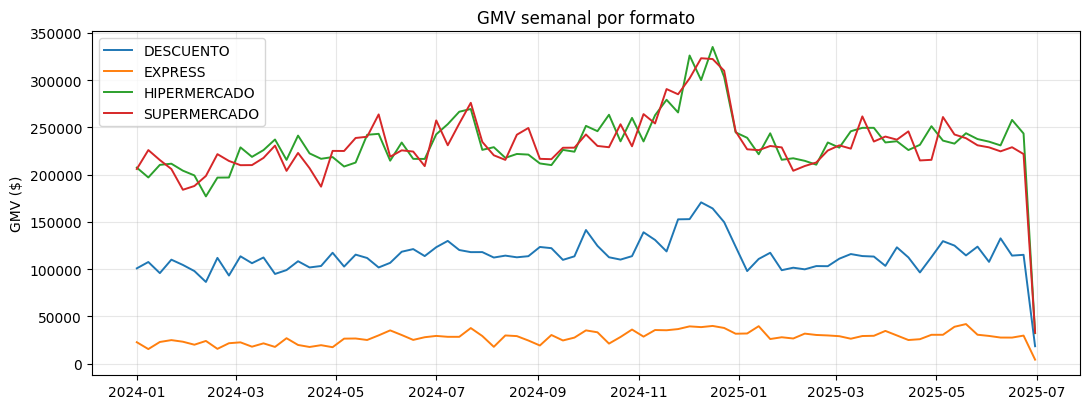

Sensibilidad estacional (CV, mayor = más sensible):
format
EXPRESS         0.244
DESCUENTO       0.165
SUPERMERCADO    0.154
HIPERMERCADO    0.152

Top 3 PICOS (% vs semana previa):
wk
2024-07-01    15.0
2024-09-30    12.9
2024-02-19    12.4

Top 3 CAÍDAS:
wk
2024-12-30   -19.4
2024-07-29   -13.3
2024-06-03    -9.9


In [3]:
w = con.execute("""
SELECT st.format, DATE_TRUNC('week',t.transaction_date) wk, SUM(ti.quantity*ti.unit_price) gmv
FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
JOIN stores st ON st.store_id=t.store_id WHERE t.status='COMPLETED'
GROUP BY 1,2 ORDER BY 2""").df()
piv = w.pivot(index='wk', columns='format', values='gmv')

fig, ax = plt.subplots(figsize=(11,4.2))
for c in piv.columns: ax.plot(piv.index, piv[c], label=c, lw=1.4)
ax.set_title('GMV semanal por formato'); ax.set_ylabel('GMV ($)'); ax.legend()
plt.tight_layout(); plt.show()

# Sensibilidad estacional = coef. de variación del GMV semanal
cv = (piv.std()/piv.mean()).sort_values(ascending=False).round(3)
print("Sensibilidad estacional (CV, mayor = más sensible):"); print(cv.to_string())

# Picos y caídas (excluyendo semanas de borde incompletas)
tot = w.groupby('wk').gmv.sum().sort_index().iloc[1:-1]
chg = tot.pct_change()*100
print("\nTop 3 PICOS (% vs semana previa):"); print(chg.nlargest(3).round(1).to_string())
print("\nTop 3 CAÍDAS:"); print(chg.nsmallest(3).round(1).to_string())


**Hallazgos P1.** El formato **EXPRESS es el más sensible** a la estacionalidad (CV 0,244 vs ~0,15): al ser tiendas pequeñas, cada semana pesa proporcionalmente más.
- **Picos:** 2024-07-01 (+15%, quincena/medio aguinaldo de mitad de año), 2024-09-30 (+12,9%, cierre de mes), 2024-02-19 (+12,4%, recuperación post-enero).
- **Caídas:** 2024-12-30 (−19,4%, resaca post-Año Nuevo), 2024-07-29 (−13,3%), 2024-06-03 (−9,9%).
- *Nota de calidad:* la última semana (2025-06-30) es parcial; se excluyó para no reportar un falso desplome de −85%.

### Pregunta 2 — Pareto de categorías por formato (HIPERMERCADO vs DESCUENTO)

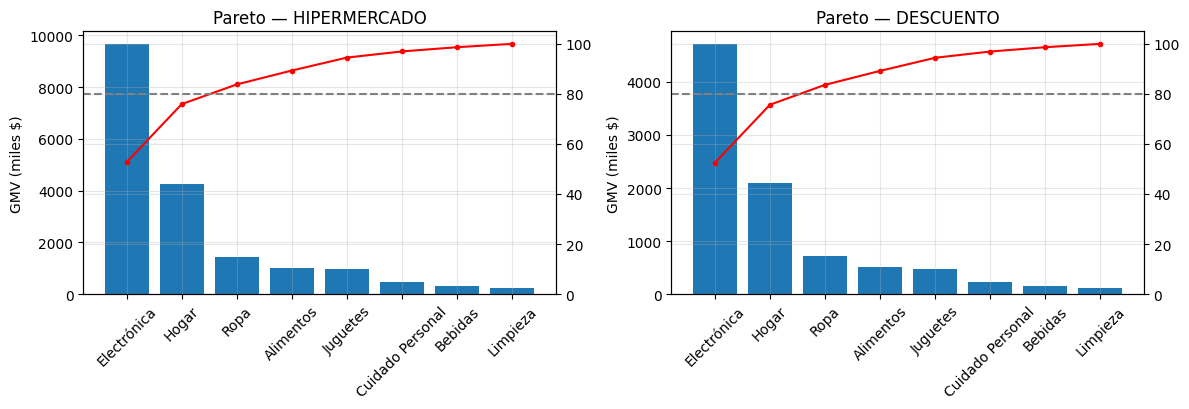

HIPERMERCADO: categorías hasta el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']
DESCUENTO: categorías hasta el 80% del GMV -> ['Electrónica', 'Hogar', 'Ropa']


In [4]:
catf = con.execute("""
SELECT st.format, p.category, SUM(ti.quantity*ti.unit_price) gmv
FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
JOIN stores st ON st.store_id=t.store_id JOIN products p ON p.item_id=ti.item_id
WHERE t.status='COMPLETED' GROUP BY 1,2""").df()

fig, axes = plt.subplots(1,2, figsize=(12,4.2))
for ax, fmt in zip(axes, ['HIPERMERCADO','DESCUENTO']):
    d = catf[catf.format==fmt].sort_values('gmv', ascending=False).copy()
    d['cum'] = 100*d.gmv.cumsum()/d.gmv.sum()
    ax.bar(d.category, d.gmv/1e3); ax.set_title(f'Pareto — {fmt}'); ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('GMV (miles $)')
    a2 = ax.twinx(); a2.plot(d.category, d.cum, 'r-o', ms=3); a2.axhline(80, ls='--', c='gray'); a2.set_ylim(0,105)
plt.tight_layout(); plt.show()

for fmt in ['HIPERMERCADO','DESCUENTO']:
    d = catf[catf.format==fmt].sort_values('gmv', ascending=False).copy(); d['cum']=100*d.gmv.cumsum()/d.gmv.sum()
    top = list(d.category.head((d.cum<=80).sum()+1))
    print(f"{fmt}: categorías hasta el 80% del GMV -> {top}")


**Hallazgo P2.** En **ambos** formatos las 3 categorías líderes son **idénticas: Electrónica, Hogar y Ropa**. Es contraintuitivo (normalmente DESCUENTO se inclinaría a Alimentos/Limpieza). Lectura probable: el dataset sintético no diferenció el mix por formato. **Recomendación:** validar con comercial si el perfil de canasta realmente no varía por formato antes de decidir surtido.

### Pregunta 3 — Cohortes de lealtad (retención y ticket)

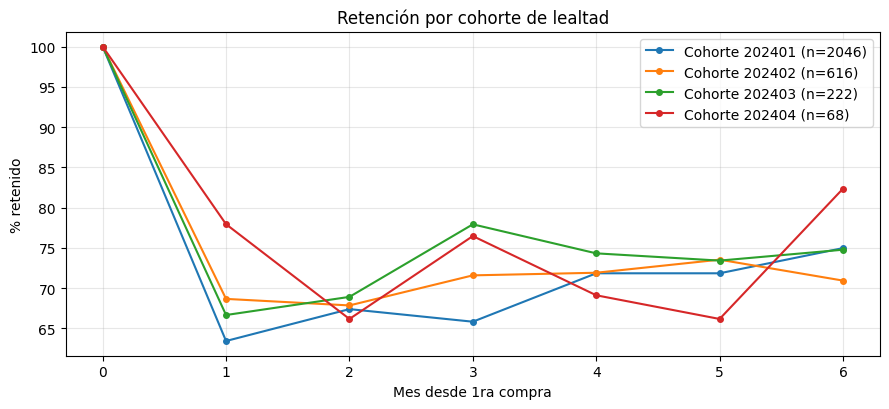

Cohorte ene-2024 (n=2046): retención m1=63%, m6=75%
Ticket cohorte ene-2024: m0=$288 -> m6=$277


In [5]:
q3 = """
WITH lt AS (SELECT t.customer_id, t.transaction_id, t.transaction_date, ti.quantity*ti.unit_price g
  FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
  WHERE t.status='COMPLETED' AND t.loyalty_card=TRUE AND t.customer_id IS NOT NULL),
txl AS (SELECT customer_id, transaction_id, MIN(transaction_date) d, SUM(g) amt FROM lt GROUP BY 1,2),
fp AS (SELECT customer_id, MIN(d) cohort FROM txl GROUP BY 1),
a AS (SELECT f.customer_id, EXTRACT(YEAR FROM f.cohort)*100+EXTRACT(MONTH FROM f.cohort) cm,
   (EXTRACT(YEAR FROM x.d)-EXTRACT(YEAR FROM f.cohort))*12+(EXTRACT(MONTH FROM x.d)-EXTRACT(MONTH FROM f.cohort)) mi, x.amt
   FROM txl x JOIN fp f ON f.customer_id=x.customer_id),
cs AS (SELECT cm, COUNT(DISTINCT customer_id) n FROM a WHERE mi=0 GROUP BY 1)
SELECT a.cm, cs.n, a.mi, COUNT(DISTINCT a.customer_id) act, AVG(a.amt) ticket
FROM a JOIN cs ON cs.cm=a.cm WHERE a.mi<=6 GROUP BY 1,2,3 ORDER BY 1,3"""
d = con.execute(q3).df(); d['ret'] = 100*d.act/d.n

fig, ax = plt.subplots(figsize=(9,4.2))
for cm in [202401,202402,202403,202404]:
    s = d[d.cm==cm]; ax.plot(s.mi, s.ret, '-o', ms=4, label=f'Cohorte {cm} (n={int(s.n.iloc[0])})')
ax.set_title('Retención por cohorte de lealtad'); ax.set_xlabel('Mes desde 1ra compra'); ax.set_ylabel('% retenido'); ax.legend()
plt.tight_layout(); plt.show()

main = d[d.cm==202401]
print(f"Cohorte ene-2024 (n={int(main.n.iloc[0])}): retención m1={main[main.mi==1].ret.iloc[0]:.0f}%, m6={main[main.mi==6].ret.iloc[0]:.0f}%")
print(f"Ticket cohorte ene-2024: m0=${main[main.mi==0].ticket.iloc[0]:.0f} -> m6=${main[main.mi==6].ticket.iloc[0]:.0f}")


**Hallazgo P3.** La cohorte robusta es **ene-2024 (2.046 clientes)**; las posteriores son chicas y las de 2025 no son leíbles (n≤2). **Retención alta y estable** (~63% m1, ~70-75% hasta m6) y **ticket plano/levemente a la baja** ($288→$277). Como la retención ya es alta pero el ticket no crece, **la palanca de valor es el gasto por visita**, no retener más.

### Pregunta 4 — Quiebres de stock y su impacto

La versión ingenua (gap≥3 días absoluto, GMV/día-con-venta) daba **$339M (7x el GMV)**. Se corrige por dos sesgos: (1) la cadencia normal del dataset es ~9 días, así que 3 días no es anómalo; (2) repartir la venta sobre días *con venta* en vez de días *calendario* sobreestima ~Nx.

Cadencia mediana entre ventas por categoría (días):
        category  intervalo_mediano_dias
            Ropa                     9.2
        Limpieza                     9.2
     Electrónica                     9.3
       Alimentos                     9.3
        Juguetes                     9.3
         Bebidas                     9.4
Cuidado Personal                     9.4
           Hogar                     9.4


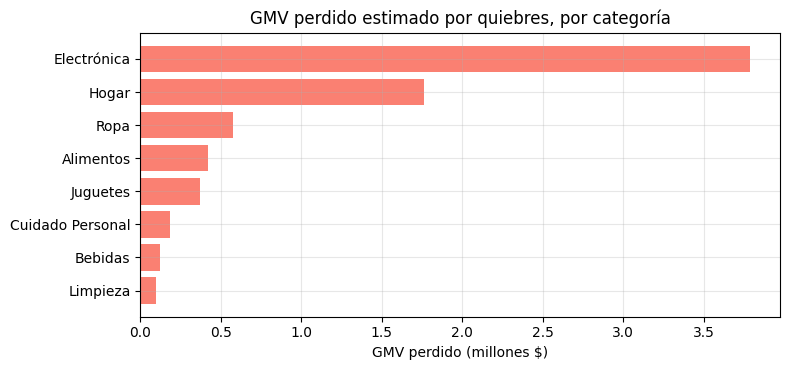

GMV perdido estimado: $7,323,196 (15.3% del GMV) — TECHO
Electrónica + Hogar = 76% del total


In [6]:
# Cadencia: confirmar que ~9 días es lo normal en todas las categorías
cad = con.execute("""
WITH dis AS (SELECT t.store_id, ti.item_id, t.transaction_date d FROM transactions t
  JOIN transaction_items ti ON ti.transaction_id=t.transaction_id WHERE t.status='COMPLETED' GROUP BY 1,2,3),
pair AS (SELECT store_id,item_id,(CAST(MAX(d)-MIN(d) AS INT)+1)*1.0/COUNT(*) iv FROM dis GROUP BY 1,2)
SELECT p.category, ROUND(MEDIAN(pr.iv),1) intervalo_mediano_dias
FROM pair pr JOIN products p ON p.item_id=pr.item_id GROUP BY 1 ORDER BY 2""").df()
print("Cadencia mediana entre ventas por categoría (días):"); print(cad.to_string(index=False))

# Versión CORREGIDA: gap anómalo vs cadencia propia del ítem + tasa diaria calendario
q5 = """
WITH dis AS (SELECT t.store_id, ti.item_id, t.transaction_date d, SUM(ti.quantity*ti.unit_price) gmv
  FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id WHERE t.status='COMPLETED' GROUP BY 1,2,3),
ps AS (SELECT store_id,item_id, COUNT(*) dcv, (CAST(MAX(d)-MIN(d) AS INT)+1)*1.0/COUNT(*) iv,
   SUM(gmv)/(CAST(MAX(d)-MIN(d) AS INT)+1) gdc FROM dis GROUP BY 1,2 HAVING COUNT(*)>=30),
g AS (SELECT d.store_id,d.item_id, CAST(LEAD(d.d) OVER(PARTITION BY d.store_id,d.item_id ORDER BY d.d)-d.d AS INT) dg
   FROM dis d JOIN ps ON ps.store_id=d.store_id AND ps.item_id=d.item_id)
SELECT pr.category, COUNT(*) gaps, SUM((g.dg-1)*ps.gdc) gmv_perdido
FROM g JOIN ps ON ps.store_id=g.store_id AND ps.item_id=g.item_id JOIN products pr ON pr.item_id=g.item_id
WHERE g.dg-1>=3 AND g.dg > 3*ps.iv GROUP BY 1 ORDER BY 3 DESC"""
sk = con.execute(q5).df()

fig, ax = plt.subplots(figsize=(8,3.8))
ax.barh(sk.category[::-1], sk.gmv_perdido[::-1]/1e6, color='salmon')
ax.set_title('GMV perdido estimado por quiebres, por categoría'); ax.set_xlabel('GMV perdido (millones $)')
plt.tight_layout(); plt.show()

tot_perd = sk.gmv_perdido.sum()
print(f"GMV perdido estimado: ${tot_perd:,.0f} ({100*tot_perd/gmv_total:.1f}% del GMV) — TECHO")
print(f"Electrónica + Hogar = {100*sk.gmv_perdido.head(2).sum()/tot_perd:.0f}% del total")


**Hallazgo P4.** Impacto corregido: **$7,3M (~15% del GMV), un techo**. Concentrado en **Electrónica + Hogar (76%)**, categorías de alto valor unitario. **¿Demanda o abastecimiento?** No es separable con datos de ventas: la cadencia es uniforme (~9 días en todas las categorías), sin firma de quiebre. **Se requiere data de inventario/órdenes de compra** para confirmarlo; hasta entonces, tratar como cota superior y priorizar Electrónica/Hogar.

### Pregunta 5 — Hallazgo libre: EXPRESS es la mejor apuesta de expansión

In [7]:
prod = con.execute("""
SELECT st.format,
  ROUND(SUM(ti.quantity*ti.unit_price)/(SELECT SUM(size_sqm) FROM stores s2 WHERE s2.format=st.format),0) gmv_m2,
  ROUND(AVG(st.size_sqm),0) m2_promedio
FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
JOIN stores st ON st.store_id=t.store_id WHERE status='COMPLETED' GROUP BY 1 ORDER BY 2 DESC""").df()
print("Productividad por formato (período completo):"); print(prod.to_string(index=False))

# Concentración de GMV por tienda
s = con.execute("""SELECT t.store_id, SUM(ti.quantity*ti.unit_price) gmv FROM transactions t
  JOIN transaction_items ti ON ti.transaction_id=t.transaction_id WHERE status='COMPLETED' GROUP BY 1 ORDER BY 2 DESC""").df()
s['cum']=100*s.gmv.cumsum()/s.gmv.sum()
print(f"\nConcentración: top 10/40 tiendas = {s.cum.iloc[9]:.0f}% del GMV | top 20 = {s.cum.iloc[19]:.0f}%")


Productividad por formato (período completo):
      format  gmv_m2  m2_promedio
     EXPRESS  1057.0        421.0
   DESCUENTO   588.0       1276.0
SUPERMERCADO   517.0       2353.0
HIPERMERCADO   412.0       5549.0

Concentración: top 10/40 tiendas = 44% del GMV | top 20 = 69%


**Hallazgo P5.** Triangulando tres métricas independientes, **EXPRESS es el formato de mayor retorno por capital invertido**: **$1.057/m² (2,5x los $412 del hipermercado)**, mayor crecimiento comparable (+11,6%) y ~13x menos superficie por tienda. Riesgo: es el más volátil estacionalmente → exige inventario más ágil. Contexto de foco: el top 10 de 40 tiendas concentra el 44% del GMV. **Acción: priorizar aperturas EXPRESS en la expansión.**

## Parte B — Experimento A/B (nueva exhibición)
Experimento `Exhibicion_Q3_2024`, 6 semanas (2024-09-01 a 2024-10-12). Métrica: GMV semanal por tienda.

### B.1 — Validación del experimento

In [8]:
sp = con.execute("SELECT DISTINCT store_id, variant FROM store_promotions WHERE store_id NOT IN ('TIENDA_008','TIENDA_037')").df()
groups = sp.groupby('variant').store_id.apply(list).to_dict()
print(f"CONTROL: {len(groups['CONTROL'])} tiendas | TREATMENT: {len(groups['TREATMENT'])} (excluidas 008 y 037 por doble asignación)")

def avg_weekly(stores, start, end):
    q = f"""SELECT t.store_id, DATE_TRUNC('week',t.transaction_date) wk, SUM(ti.quantity*ti.unit_price) gmv
    FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
    WHERE t.status='COMPLETED' AND t.store_id IN ({','.join(chr(39)+s+chr(39) for s in stores)})
      AND t.transaction_date BETWEEN DATE '{start}' AND DATE '{end}' GROUP BY 1,2"""
    return con.execute(q).df().groupby('store_id').gmv.mean()

PRE=('2024-07-21','2024-08-31'); TEST=('2024-09-01','2024-10-12')
pre_c, pre_t = avg_weekly(groups['CONTROL'],*PRE), avg_weekly(groups['TREATMENT'],*PRE)
_, p_base = stats.ttest_ind(pre_t, pre_c, equal_var=False)
print(f"\nBaseline pre-test (GMV semanal/tienda): CONTROL={pre_c.mean():,.0f}  TREATMENT={pre_t.mean():,.0f}  p={p_base:.3f}")
st = con.execute("SELECT store_id, format, size_sqm FROM stores").df()
for g in ['CONTROL','TREATMENT']:
    sub = st[st.store_id.isin(groups[g])]
    print(f"  {g}: tamaño medio={sub.size_sqm.mean():,.0f} m² | formatos={sub.format.value_counts().to_dict()}")


CONTROL: 18 tiendas | TREATMENT: 20 (excluidas 008 y 037 por doble asignación)

Baseline pre-test (GMV semanal/tienda): CONTROL=15,052  TREATMENT=11,150  p=0.061
  CONTROL: tamaño medio=3,100 m² | formatos={'SUPERMERCADO': 8, 'HIPERMERCADO': 5, 'DESCUENTO': 4, 'EXPRESS': 1}
  TREATMENT: tamaño medio=1,813 m² | formatos={'DESCUENTO': 8, 'SUPERMERCADO': 7, 'EXPRESS': 3, 'HIPERMERCADO': 2}


**B.1.** Las dos tiendas con doble asignación se excluyeron. **Los grupos NO están balanceados:** CONTROL tiene tiendas más grandes (3.100 m², 5 hipermercados) y TREATMENT más chicas (1.813 m², 8 de descuento); el baseline difería (p=0,061, en el límite). **Conclusión:** una comparación directa estaría sesgada por el tamaño → se usa **diferencia-en-diferencias (DiD)**.

### B.2 — Resultado en GMV: comparación ingenua vs DiD

INGENUA: CONTROL=14,119 TREATMENT=11,720 -> -17.0% (p=0.241)  [sesgada]

DiD: CONTROL -6.2% vs TREATMENT +5.1%
  Efecto causal = $+1,503/semana/tienda = +10.0% lift
  p-value=0.004  IC95%=[$508, $2,498]  -> SIGNIFICATIVO


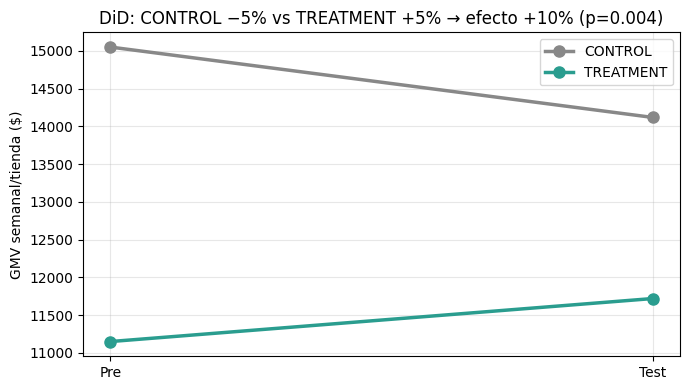

In [9]:
# Ingenua (incorrecta): comparar niveles durante el test
test_c, test_t = avg_weekly(groups['CONTROL'],*TEST), avg_weekly(groups['TREATMENT'],*TEST)
_, p_naive = stats.ttest_ind(test_t, test_c, equal_var=False)
lift_naive = 100*(test_t.mean()-test_c.mean())/test_c.mean()
print(f"INGENUA: CONTROL={test_c.mean():,.0f} TREATMENT={test_t.mean():,.0f} -> {lift_naive:+.1f}% (p={p_naive:.3f})  [sesgada]")

# DiD (correcta): comparar el cambio pre->test entre grupos
dc = (test_c - pre_c).dropna(); dt = (test_t - pre_t).dropna()
_, p_did = stats.ttest_ind(dt, dc, equal_var=False)
eff = dt.mean() - dc.mean()
se = np.sqrt(dt.var(ddof=1)/len(dt) + dc.var(ddof=1)/len(dc))
dfw = (dt.var(ddof=1)/len(dt)+dc.var(ddof=1)/len(dc))**2 / ((dt.var(ddof=1)/len(dt))**2/(len(dt)-1)+(dc.var(ddof=1)/len(dc))**2/(len(dc)-1))
tc = stats.t.ppf(0.975, dfw); ci = (eff-tc*se, eff+tc*se)
print(f"\nDiD: CONTROL {100*dc.mean()/pre_c.mean():+.1f}% vs TREATMENT {100*dt.mean()/pre_t.mean():+.1f}%")
print(f"  Efecto causal = ${eff:+,.0f}/semana/tienda = {100*eff/pre_c.mean():+.1f}% lift")
print(f"  p-value={p_did:.3f}  IC95%=[${ci[0]:,.0f}, ${ci[1]:,.0f}]  -> {'SIGNIFICATIVO' if p_did<0.05 else 'no significativo'}")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(['Pre','Test'], [pre_c.mean(),test_c.mean()], '-o', lw=2.5, ms=8, color='#888', label='CONTROL')
ax.plot(['Pre','Test'], [pre_t.mean(),test_t.mean()], '-o', lw=2.5, ms=8, color='#2a9d8f', label='TREATMENT')
ax.set_title('DiD: CONTROL −5% vs TREATMENT +5% → efecto +10% (p=0.004)'); ax.set_ylabel('GMV semanal/tienda ($)'); ax.legend()
plt.tight_layout(); plt.show()


**B.2.** La comparación ingenua daba **−17% (p=0,24)** — conclusión equivocada, artefacto del desbalance. El **DiD** revela lo contrario: CONTROL cayó −5% y TREATMENT creció +5%, dando un **efecto causal de +$1.503/semana/tienda = +10% lift, p=0,004, IC95% [+508, +2.498]**. Positivo y significativo.

### B.3 — ¿Ticket o frecuencia? · B.4 — Decisión

In [10]:
def ticket_freq(stores, start, end):
    q=f"""SELECT t.store_id, COUNT(DISTINCT t.transaction_id) ntx, SUM(ti.quantity*ti.unit_price) gmv
    FROM transactions t JOIN transaction_items ti ON ti.transaction_id=t.transaction_id
    WHERE t.status='COMPLETED' AND t.store_id IN ({','.join(chr(39)+s+chr(39) for s in stores)})
      AND t.transaction_date BETWEEN DATE '{start}' AND DATE '{end}' GROUP BY 1"""
    d=con.execute(q).df(); d['ticket']=d.gmv/d.ntx; return d
tcf=ticket_freq(groups['CONTROL'],*TEST); ttf=ticket_freq(groups['TREATMENT'],*TEST)
_,p_tk=stats.ttest_ind(ttf.ticket,tcf.ticket,equal_var=False)
print(f"Ticket: CONTROL={tcf.ticket.mean():.1f} TREATMENT={ttf.ticket.mean():.1f} ({100*(ttf.ticket.mean()-tcf.ticket.mean())/tcf.ticket.mean():+.1f}%, p={p_tk:.2f})")
print("-> ticket plano: el efecto viene de VOLUMEN de transacciones, no de canastas más caras.")


Ticket: CONTROL=278.9 TREATMENT=273.7 (-1.9%, p=0.41)
-> ticket plano: el efecto viene de VOLUMEN de transacciones, no de canastas más caras.


**B.3.** El ticket promedio se mantuvo plano (−1,9%, p=0,41, no significativo): el lift proviene de **mayor volumen/tráfico**, no de canastas más caras.

**B.4 — Decisión de negocio: IMPLEMENTAR la nueva exhibición.**
- Lift +10%, significativo y robusto al DiD; incluso el extremo inferior del IC es positivo (+3,4%).
- Condición: validar que el **costo por tienda < margen incremental** del +10% (con ticket constante y solo más volumen, el costo marginal es bajo → ROI probablemente favorable).
- **¿Y si p=0,08?** No sería significativo al 95%, pero con estimador puntual positivo **no concluiría "no funciona"**: un p=0,08 con efecto relevante suele indicar **falta de poder** (pocas tiendas/semanas). Acción: **extender el test** o hacer rollout por fases midiendo con DiD, no descartar la idea.